# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rifkiay/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Final queue combines two signals: the Week-4 baseline rule (stronger at Precision@50 per Week 5-6 testing) as the primary rank, with the Week-5/6 Random Forest model as a confidence check. When both signals agree, confidence is higher; when only the baseline fires, the page still gets flagged but is marked for extra scrutiny — this reflects the honest, mixed comparison from Week 6 rather than picking one method and hiding the other's disagreement.

In [1]:
import duckdb
import os
from dotenv import load_dotenv
import pandas as pd

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

rel = "hf://datasets/FlyRank/internship-warehouse"
month_path = f"{rel}/fact_content_daily_performance/month=2026-03/*.parquet"

# FEATURE window: March 1-15
features_raw = con.sql(f"""
SELECT
    content_hash_id,
    client_hash_id,
    AVG(gsc_avg_position) AS avg_position,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    SUM(ga4_sessions) AS sessions,
    SUM(ga4_engaged_sessions) AS engaged_sessions,
    SUM(scroll_events) AS scroll_events,
    SUM(ga4_pageviews) AS pageviews,
    SUM(sessions_ai) AS ai_sessions
FROM read_parquet('{month_path}')
WHERE gsc_data_available IS TRUE
  AND report_date BETWEEN '2026-03-01' AND '2026-03-15'
GROUP BY content_hash_id, client_hash_id
HAVING SUM(gsc_impressions) > 0
""").df()

# LABEL window: March 16-31
label_raw = con.sql(f"""
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS impressions_label_window
FROM read_parquet('{month_path}')
WHERE gsc_data_available IS TRUE
  AND report_date BETWEEN '2026-03-16' AND '2026-03-31'
GROUP BY content_hash_id
""").df()

data = features_raw.merge(label_raw, on="content_hash_id", how="inner")

data["ctr"] = (data["clicks"] / data["impressions"] * 100).fillna(0)
data["engagement_rate"] = (data["engaged_sessions"] / data["sessions"].replace(0, pd.NA)).fillna(0)
data["scroll_rate"] = (data["scroll_events"] / data["pageviews"].replace(0, pd.NA)).fillna(0)
data["ai_session_ratio"] = (data["ai_sessions"] / data["sessions"].replace(0, pd.NA)).fillna(0)

data["is_declining"] = (
    data["impressions_label_window"] < data["impressions"] * 0.8
).astype(int)

X_cols = ["avg_position", "impressions", "clicks", "ctr", 
          "engagement_rate", "scroll_rate", "ai_session_ratio"]

print("Total pages:", len(data))

Total pages: 141467


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.ensemble import RandomForestClassifier

# Retrain the model on ALL data for deployment scoring 
X_all = data[X_cols].fillna(0)
y_all = data["is_declining"]
model_final = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
model_final.fit(X_all, y_all)
data["model_score"] = model_final.predict_proba(X_all)[:, 1]

# Recompute the Week-4 baseline score on all pages
def tier_of(pos):
    if pos <= 0: return "no_data"
    elif pos <= 3: return "top_3"
    elif pos <= 10: return "page_1"
    elif pos <= 20: return "striking"
    elif pos <= 50: return "page_3_5"
    else: return "deep"

expected_ctr = {"top_3": 0.381, "page_1": 0.323, "striking": 0.315,
                "page_3_5": 0.137, "deep": 0.044, "no_data": None}

data["position_tier"] = data["avg_position"].apply(tier_of)
data["expected_ctr"] = data["position_tier"].map(expected_ctr)

def ctr_gap(row):
    if row["expected_ctr"] is None or row["expected_ctr"] == 0:
        return 0
    gap = (row["expected_ctr"] - row["ctr"]) / row["expected_ctr"]
    return max(0, min(1, gap))

data["ctr_gap_score"] = data.apply(ctr_gap, axis=1)
data["striking_distance_score"] = (
    (data["position_tier"] == "striking") & (data["impressions"] >= 20)
).astype(int)
data["baseline_score"] = 0.5 * data["ctr_gap_score"] + 0.5 * data["striking_distance_score"]

# Combine: baseline is primary rank, model is a confidence flag
def reason_and_action(row):
    model_agrees = row["model_score"] >= 0.5
    if row["ctr_gap_score"] >= 0.3 and model_agrees:
        return "high_confidence_low_ctr", "review_ctr_and_snippet", "High"
    elif row["ctr_gap_score"] >= 0.3 and not model_agrees:
        return "baseline_only_low_ctr", "review_ctr_and_snippet", "Medium — model disagrees, verify manually"
    elif row["striking_distance_score"] == 1 and model_agrees:
        return "high_confidence_striking_distance", "push_to_page_one", "High"
    elif row["striking_distance_score"] == 1 and not model_agrees:
        return "baseline_only_striking_distance", "push_to_page_one", "Medium — model disagrees, verify manually"
    else:
        return "no_action_needed", "monitor", "N/A"

data[["reason_code", "action", "confidence"]] = data.apply(
    lambda row: pd.Series(reason_and_action(row)), axis=1
)

ranked_queue = data.sort_values(
    ["baseline_score", "impressions"], ascending=[False, False]
).reset_index(drop=True)

print("Total pages in queue:", len(ranked_queue))
print("\nReason code distribution:")
print(ranked_queue["reason_code"].value_counts())
print("\nTop 10:")
ranked_queue[["content_hash_id", "baseline_score", "model_score", "reason_code", "action", "confidence"]].head(10)

Total pages in queue: 141467

Reason code distribution:
reason_code
high_confidence_low_ctr              64104
baseline_only_low_ctr                40236
no_action_needed                     30274
baseline_only_striking_distance       6343
high_confidence_striking_distance      510
Name: count, dtype: int64

Top 10:


,content_hash_id,baseline_score,model_score,reason_code,action,confidence
0,content_1ff6231687184dec,1.0,0.592118,high_confidence_low_ctr,review_ctr_and_snippet,High
1,content_7b3c4c2ef098f192,1.0,0.480143,baseline_only_low_ctr,review_ctr_and_snippet,"Medium — model disagrees, verify manually"
2,content_551a522809e0358c,1.0,0.591105,high_confidence_low_ctr,review_ctr_and_snippet,High
3,content_4c163d9bcbe54fb3,1.0,0.503744,high_confidence_low_ctr,review_ctr_and_snippet,High
4,content_dd76ae989a61d4f6,1.0,0.516856,high_confidence_low_ctr,review_ctr_and_snippet,High
5,content_cc9732f0da1d8d2d,1.0,0.577928,high_confidence_low_ctr,review_ctr_and_snippet,High
6,content_e0a191fda43bf0fc,1.0,0.598223,high_confidence_low_ctr,review_ctr_and_snippet,High
7,content_b384057451493e31,1.0,0.580314,high_confidence_low_ctr,review_ctr_and_snippet,High
8,content_59a897a6ca5418df,1.0,0.577519,high_confidence_low_ctr,review_ctr_and_snippet,High
9,content_e4ba7342f9f80970,1.0,0.594569,high_confidence_low_ctr,review_ctr_and_snippet,High


**Cost/value thinking:** each review costs a reviewer roughly 10-20 minutes (open page, check numbers, decide on an edit). Against that: a `high_confidence_low_ctr` page averaging thousands of impressions could realistically recover a meaningful share of its CTR gap if the snippet issue is real — even a small CTR lift on a high-impression page usually outweighs the review cost. The `Medium` confidence pages cost the same to review but have a real chance of being a false positive (per Week 5-6's error analysis), so they're a weaker bet per minute spent — this is why they're ranked below `High` confidence pages in the queue, not excluded outright.

**Archetype → action mapping:** each reason code represents a distinct page situation, not just a score threshold:

| Archetype (page situation) | Reason code | Action |
|---|---|---|
| Visible but under-clicked — good position, weak snippet appeal | `high_confidence_low_ctr` / `baseline_only_low_ctr` | `review_ctr_and_snippet` |
| Almost there — ranks just outside page 1 with real demand already | `high_confidence_striking_distance` / `baseline_only_striking_distance` | `push_to_page_one` |
| Stable / no strong signal either way | `no_action_needed` | `monitor` |

The `high_confidence_*` vs `baseline_only_*` split within each archetype isn't a different situation — it's a confidence tag showing whether the Week-5/6 model independently agrees with the baseline's read of that situation.

**Decay/refresh insight (context, not directly modeled):** this playbook's own features (`avg_position`, `ctr`, engagement signals) don't include content freshness (`days_since_last_update`), so refresh timing isn't part of this specific score. But the FlyRank research paper's Finding #4 found refreshing mature content produced a 3.2x health boost and 57x more impressions in their portfolio, and Finding #2 showed performance dropping sharply after ~270 days without an update. This is external, directional evidence — not proven on this dataset — but it supports treating "how long since last update" as a reasonable secondary factor a reviewer can weigh alongside this queue's ranking, especially for `no_action_needed` pages that are also old and untouched, which this playbook currently doesn't flag at all.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** this playbook is for a content reviewer or SEO lead deciding which pages to check first when review capacity is limited (e.g. 50-100 pages per cycle). It ranks pages by combined baseline + model signal so the reviewer starts with the highest-confidence, highest-opportunity pages.

**Who should NOT rely on this alone:** anyone making irreversible or high-stakes decisions (e.g. deleting a page, cutting a client's content budget) without independently verifying the underlying numbers.

**When this stops being valid:**
- **Data staleness:** built on March 2026 data only (a single month) — search behavior can shift seasonally, so this queue should be treated as stale after roughly 60-90 days without a refresh.
- **New pages:** pages published after March 2026 aren't in this queue at all — it only covers content that existed and had traffic in the training window.
- **Client-specific drift:** the model was trained across ~43 clients; a client with a very different content style or industry than the training set may get less reliable scores.
- **The `is_declining` label is a proxy**, not a confirmed outcome — it reflects an impressions drop between two windows within March, not a guarantee that manually confirmed the page is now underperforming for a specific business reason (e.g. seasonality, a known site migration).

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a human must check before acting on any recommendation:**
1. Open the actual page and confirm the CTR/position numbers still look current (not from a page that was recently redesigned or redirected).
2. Check whether the page belongs to a known seasonal topic (e.g. holiday content) — a "decline" flag during an off-season is expected and doesn't need a rewrite.
3. For `baseline_only_*` reason codes (Medium confidence), manually verify the page before spending significant editing time — the model disagreeing is a real signal worth a second look, not noise to ignore.
4. Cross-check the client has active tracking (`gsc_data_available IS TRUE` for recent days) — a page with stale tracking can look "declining" simply because data stopped flowing in, not because performance dropped.

**No-go list — this should NEVER be automated:**
- **Auto-publishing content changes** based on this queue. Every recommendation needs a human editor's judgment before anything goes live.
- **Auto-deprioritizing or removing pages** (pruning) without a human confirming there's no legal, compliance, or brand reason to keep the page regardless of traffic.
- **Using this score as a performance metric for a content writer or team** — this is a prioritization tool for review capacity, not a quality judgment on who wrote the page.
- **Feeding this score into a client-facing report as a guaranteed forecast** — it's a proxy-based, decision-support signal, not a validated prediction of future outcomes (per Week 6's audit).
- **Combining this with any FlyRank product flag** (`health_score`, `priority_score`) as if they were independently confirming each other — they weren't built to be combined this way, and doing so would double-count the same underlying signals.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signs this playbook has gone stale and needs a refresh:**

1. **Time-based trigger:** more than 60-90 days since the training data window (March 2026) — search behavior, algorithm updates, or seasonal shifts accumulate enough by then to make the patterns less reliable.

2. **Volume drift:** if the total impression volume for the tracked pages changes by more than ~30% month-over-month at the portfolio level, the baseline's `expected_ctr` per position tier (calibrated on March data) may no longer reflect current reality.

3. **Coverage drift:** if `gsc_data_available` or `ga4_data_available` rates drop significantly from what was observed in Week 3 (GA4 coverage was already low, ~4%) — worsening coverage means the confidence-check features (`engagement_rate`, `scroll_rate`) become even less informative.

4. **New client onboarding:** if a client with a fundamentally different content type or industry joins, the model should be re-validated on that client's data before trusting its scores — it was trained on ~43 clients from a specific mix.

5. **Precision drift check:** if this were deployed, periodically sampling the top 50 recommendations and manually checking how many were "correct" in hindsight (a live Precision@K check) would be the most direct signal that retraining is overdue — a meaningful drop from the ~0.34-0.46 range observed in Weeks 5-6 would be the trigger.

**Retrain cadence (recommendation, not enforced by this notebook):** monthly, using a rolling window of the most recent complete month — matching how this notebook itself was built on March 2026 data.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exporting the ranked queue to `work/outputs/` (regenerated each run, not committed) and a metrics summary to `work/outputs/*.json` (committed — these are the receipts the paper's numbers will trace back to next week).

Queue exported: 141467 rows -> d:\flayrank\flyrank-ml-internship-starter\work\outputs\action_playbook_queue.csv
Metrics exported -> d:\flayrank\flyrank-ml-internship-starter\work\outputs\playbook_metrics.json
{
  "generated_at": "2026-08-25T13:17:57.871243",
  "data_window": {
    "feature_window": "2026-03-01 to 2026-03-15",
    "label_window": "2026-03-16 to 2026-03-31"
  },
  "total_pages_scored": 141467,
  "reason_code_distribution": {
    "high_confidence_low_ctr": 64104,
    "baseline_only_low_ctr": 40236,
    "no_action_needed": 30274,
    "baseline_only_striking_distance": 6343,
    "high_confidence_striking_distance": 510
  },
  "model_vs_baseline": {
    "baseline_precision_at_50": 0.46,
    "model_precision_at_50_honest_split": 0.34,
    "model_roc_auc_honest_split": 0.598,
    "baseline_roc_auc": 0.521,
    "note": "Baseline wins Precision@50; model wins ROC AUC. Mixed result, see Week 5-6 notebooks."
  },
  "leakage_audit": {
    "max_feature_label_correlation": 0.020407,


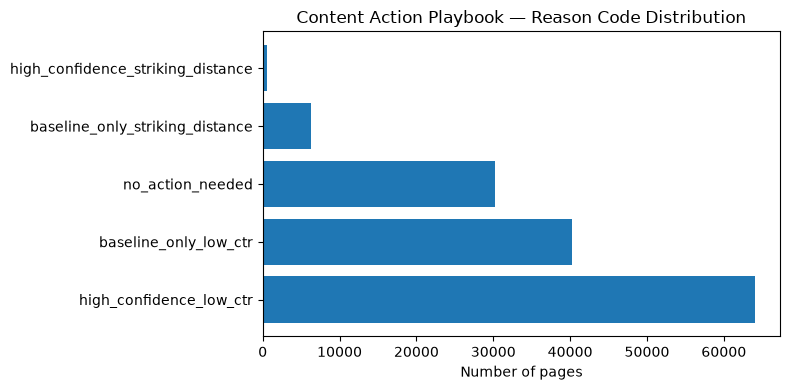

Figure saved -> d:\flayrank\flyrank-ml-internship-starter\work\figures\reason_code_distribution.png


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import json
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

# Paths relative to work/notebooks/
outputs_dir = Path.cwd().parent / "outputs"
figures_dir = Path.cwd().parent / "figures"
outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# 1. Export the full ranked queue (CSV — regenerated, not committed)
export_cols = ["content_hash_id", "client_hash_id", "avg_position", "impressions",
               "ctr", "baseline_score", "model_score", "reason_code", "action", "confidence"]
ranked_queue[export_cols].to_csv(outputs_dir / "action_playbook_queue.csv", index=False)
print(f"Queue exported: {len(ranked_queue)} rows -> {outputs_dir / 'action_playbook_queue.csv'}")

# 2. Export metrics JSON (committed — the paper's numbers trace back to this)
metrics_summary = {
    "generated_at": datetime.now().isoformat(),
    "data_window": {"feature_window": "2026-03-01 to 2026-03-15", "label_window": "2026-03-16 to 2026-03-31"},
    "total_pages_scored": len(ranked_queue),
    "reason_code_distribution": ranked_queue["reason_code"].value_counts().to_dict(),
    "model_vs_baseline": {
        "baseline_precision_at_50": 0.46,
        "model_precision_at_50_honest_split": 0.34,
        "model_roc_auc_honest_split": 0.598,
        "baseline_roc_auc": 0.521,
        "note": "Baseline wins Precision@50; model wins ROC AUC. Mixed result, see Week 5-6 notebooks."
    },
    "leakage_audit": {
        "max_feature_label_correlation": 0.020407,
        "injected_leak_column_auc": 0.999,
        "honest_auc_without_leak": 0.598
    },
    "high_confidence_flagged_pages": int((ranked_queue["confidence"] == "High").sum()),
    "medium_confidence_flagged_pages": int(ranked_queue["confidence"].str.contains("Medium", na=False).sum())
}

with open(outputs_dir / "playbook_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print(f"Metrics exported -> {outputs_dir / 'playbook_metrics.json'}")
print(json.dumps(metrics_summary, indent=2))

fig, ax = plt.subplots(figsize=(8, 4))
reason_counts = ranked_queue["reason_code"].value_counts()
ax.barh(reason_counts.index, reason_counts.values)
ax.set_xlabel("Number of pages")
ax.set_title("Content Action Playbook — Reason Code Distribution")
plt.tight_layout()
plt.savefig(figures_dir / "reason_code_distribution.png", dpi=150)
plt.show()
print(f"Figure saved -> {figures_dir / 'reason_code_distribution.png'}")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.